# Homework 7
## Part A
### Prompt
"1) run K-means and DBSCAN and show a case where DBSCAN
beats K-means; (2) use silhouette analysis to choose the number of clusters; (3) run a
1-nearest-neighbor classifier on a labeled set. dont build new sections the notebook is pruely for refer3ence i am generating a completely new project withthe txt file" + d_swap.txt, clustering.ipnyb
### Output

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

RANDOM_STATE = 42

#### 1. Load and inspect the data

In [3]:
swap = pd.read_csv('d_swap.txt', sep='\t', skiprows=1)
swap.columns = [c.strip().lstrip('%') for c in swap.columns]
tenors = swap.columns.tolist()
print(swap.shape)
swap.head()

(1257, 8)


,swp1y,swp2y,swp3y,sw4y,sw5y,sw7y,sw10y,sw30y
0,7.10,7.16,7.17,7.17,7.17,7.20,7.24,7.24
1,7.03,7.06,7.07,7.07,7.08,7.11,7.14,7.16
2,7.07,7.13,7.14,7.15,7.16,7.19,7.21,7.21
3,7.01,7.04,7.06,7.06,7.07,7.10,7.14,7.14
4,7.04,7.09,7.11,7.13,7.14,7.17,7.20,7.19


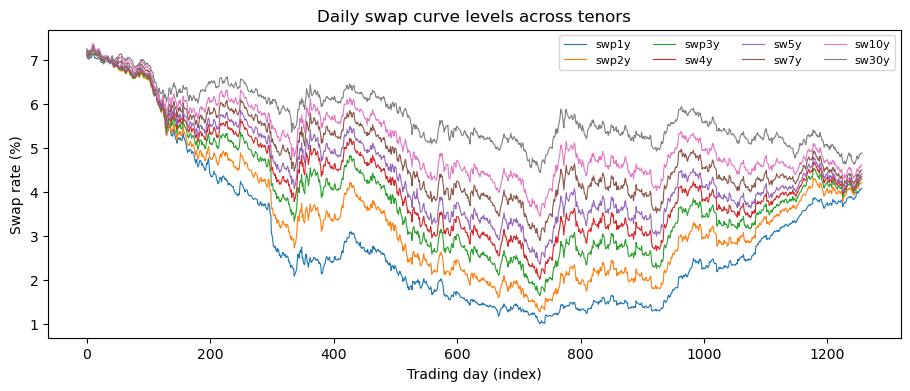

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
for t in tenors:
    ax.plot(swap.index, swap[t], lw=0.8, label=t)
ax.set_xlabel('Trading day (index)')
ax.set_ylabel('Swap rate (%)')
ax.set_title('Daily swap curve levels across tenors')
ax.legend(ncol=4, fontsize=8)
plt.show()

The curve drifts from roughly 7% down to under 2% and back up again -- a long, mostly smooth trend across the sample. That matters for the two analyses below: the **levels** are used to define rate *regimes* (section 2), while the **day-to-day changes** are used to find isolated shock days (section 3).

#### 2. Silhouette Analysis: How Many Rate Regimes?
We treat each day's 8-tenor curve as a feature vector and ask K-Means/silhouette analysis how many distinct **level regimes** (e.g. high-rate/flat vs. low-rate/steep) the data supports.

c:\Users\sromerod3\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\sromerod3\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\sromerod3\AppData\Local\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\sromerod3\AppData\Local\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, exec

2 0.5895
3 0.5504


c:\Users\sromerod3\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
c:\Users\sromerod3\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


4 0.4949
5 0.5153


c:\Users\sromerod3\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
c:\Users\sromerod3\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


6 0.5073
7 0.5093


c:\Users\sromerod3\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
c:\Users\sromerod3\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


8 0.5048


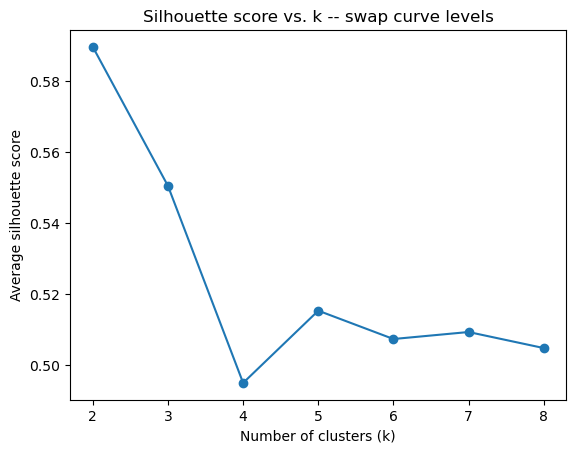

In [5]:
X_level = StandardScaler().fit_transform(swap.values)

range_n_clusters = [2, 3, 4, 5, 6, 7, 8]
sil_scores = []
for k in range_n_clusters:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_level)
    score = silhouette_score(X_level, labels)
    sil_scores.append(score)
    print(k, round(score, 4))

plt.plot(range_n_clusters, sil_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Average silhouette score')
plt.title('Silhouette score vs. k -- swap curve levels')
plt.show()

Best k by average silhouette score: 2


c:\Users\sromerod3\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


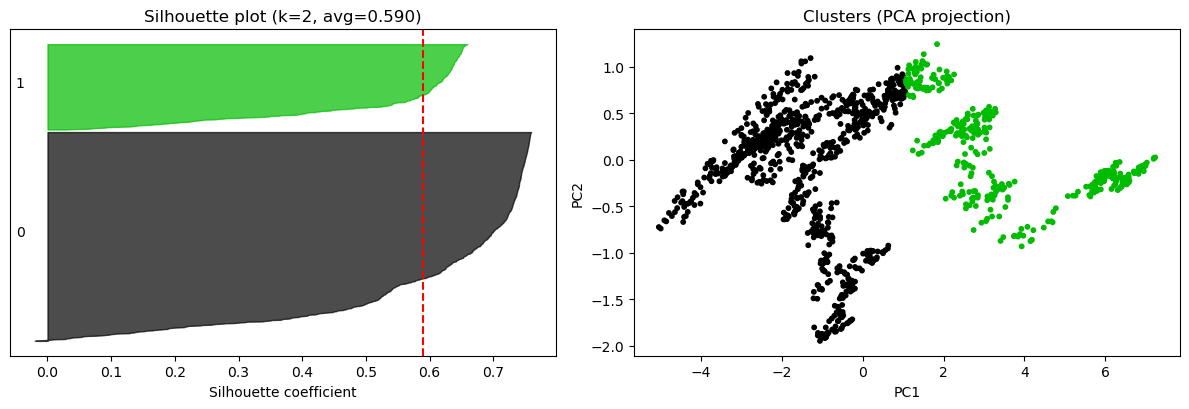

In [6]:
def silhouette_diagram(X, n_clusters, random_state=RANDOM_STATE):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
    clusterer = KMeans(n_clusters=n_clusters, n_init=10, random_state=random_state)
    cluster_labels = clusterer.fit_predict(X)
    silhouette_avg = silhouette_score(X, cluster_labels)
    sample_vals = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        ith = sample_vals[cluster_labels == i]
        ith.sort()
        size_i = ith.shape[0]
        y_upper = y_lower + size_i
        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith, facecolor=color, edgecolor=color, alpha=0.7)
        ax1.text(-0.05, y_lower + 0.5 * size_i, str(i))
        y_lower = y_upper + 10
    ax1.axvline(x=silhouette_avg, color='red', linestyle='--')
    ax1.set_title(f'Silhouette plot (k={n_clusters}, avg={silhouette_avg:.3f})')
    ax1.set_xlabel('Silhouette coefficient')
    ax1.set_yticks([])

    pca = PCA(n_components=2, random_state=random_state).fit(X)
    X2 = pca.transform(X)
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(X2[:, 0], X2[:, 1], c=colors, s=10)
    ax2.set_title('Clusters (PCA projection)')
    ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')
    plt.tight_layout()
    plt.show()
    return cluster_labels

best_k = range_n_clusters[int(np.argmax(sil_scores))]
print('Best k by average silhouette score:', best_k)
regime_labels = silhouette_diagram(X_level, best_k)

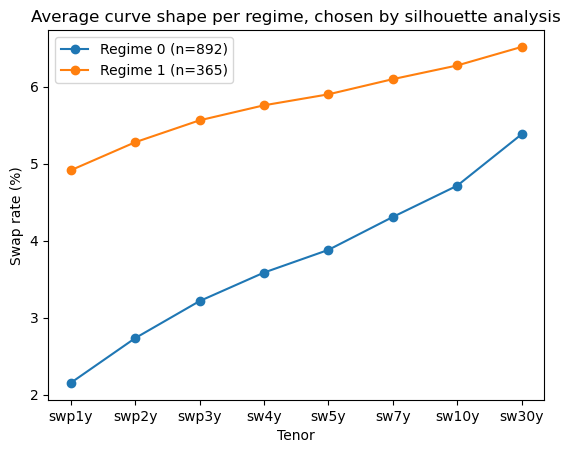

,swp1y,swp2y,swp3y,sw4y,sw5y,sw7y,sw10y,sw30y
regime,,,,,,,,
0,2.153509,2.734406,3.215908,3.585975,3.880796,4.308195,4.714417,5.382040
1,4.914301,5.278384,5.562986,5.758164,5.900658,6.097753,6.275452,6.516219


In [7]:
regime_means = swap.groupby(regime_labels).mean()
regime_means.index.name = 'regime'

for r in regime_means.index:
    plt.plot(tenors, regime_means.loc[r], marker='o', label=f'Regime {r} (n={sum(regime_labels==r)})')
plt.xlabel('Tenor'); plt.ylabel('Swap rate (%)')
plt.title('Average curve shape per regime, chosen by silhouette analysis')
plt.legend()
plt.show()
regime_means

#### 3. Where DBSCAN Beats K-Means: Isolating Rate-Shock Days

K-Means on curve *levels* works fine above because the regimes are broad, dense bands. But K-Means has a blind spot: it **must** assign every point to a cluster, even genuine outliers, and a handful of extreme points can drag a centroid away from where the bulk of that cluster actually sits.

To expose this, we switch features: instead of curve *levels*, we look at **day-to-day changes** in each tenor. Most days see small, quiet moves; a few days see a sharp, simultaneous jump across the curve (a rate shock). Those shock days are sparse and isolated in feature space -- exactly the situation DBSCAN is built for, and exactly the situation that breaks K-Means's assumption that every cluster deserves a centroid.

In [8]:
diffs = swap.diff().dropna()
X_diff = StandardScaler().fit_transform(diffs.values)

# quick outlier check: days with an extreme move (|z|>4) in at least one tenor
z = pd.DataFrame(X_diff, columns=tenors)
n_outlier_days = (z.abs() > 4).any(axis=1).sum()
print(f'{n_outlier_days} days have at least one tenor move more than 4 std devs from the mean daily move.')

9 days have at least one tenor move more than 4 std devs from the mean daily move.


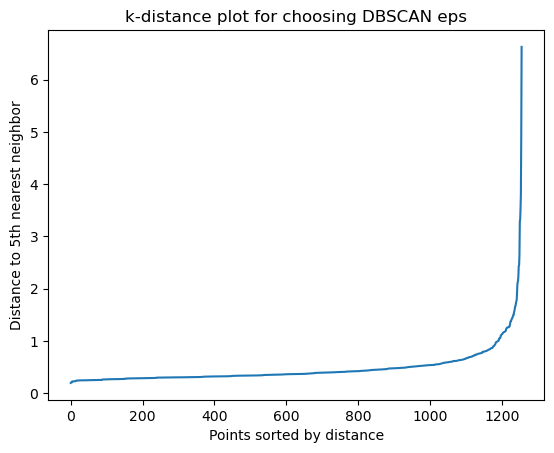

In [9]:
# k-distance plot to pick a reasonable DBSCAN eps
nn = NearestNeighbors(n_neighbors=5).fit(X_diff)
distances, _ = nn.kneighbors(X_diff)
k_dist = np.sort(distances[:, -1])

plt.plot(k_dist)
plt.ylabel('Distance to 5th nearest neighbor')
plt.xlabel('Points sorted by distance')
plt.title('k-distance plot for choosing DBSCAN eps')
plt.show()

In [10]:
eps_choice = 1.4  # read off the elbow in the k-distance plot above

kmeans_diff = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE)
labels_kmeans_diff = kmeans_diff.fit_predict(X_diff)

dbscan_diff = DBSCAN(eps=eps_choice, min_samples=5)
labels_dbscan_diff = dbscan_diff.fit_predict(X_diff)

n_noise = int((labels_dbscan_diff == -1).sum())
print('DBSCAN flagged', n_noise, 'days as noise/shock days out of', len(labels_dbscan_diff))
print('DBSCAN cluster sizes (excluding noise):',
      {c: int((labels_dbscan_diff == c).sum()) for c in sorted(set(labels_dbscan_diff)) if c != -1})

DBSCAN flagged 16 days as noise/shock days out of 1256
DBSCAN cluster sizes (excluding noise): {np.int64(0): 1240}


c:\Users\sromerod3\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


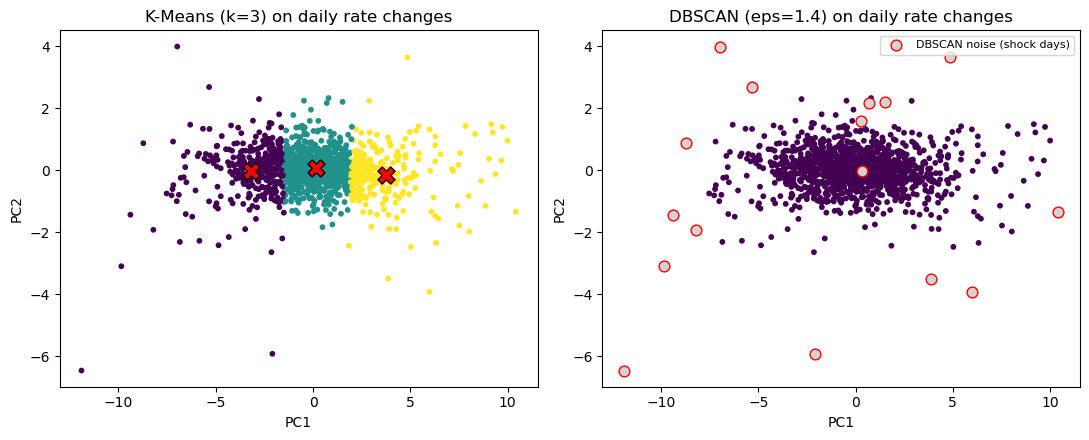

In [11]:
pca_diff = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_diff)
X_diff2 = pca_diff.transform(X_diff)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(X_diff2[:, 0], X_diff2[:, 1], c=labels_kmeans_diff, s=10, cmap='viridis')
axes[0].scatter(pca_diff.transform(kmeans_diff.cluster_centers_)[:, 0],
                pca_diff.transform(kmeans_diff.cluster_centers_)[:, 1],
                marker='X', c='red', s=150, edgecolor='k')
axes[0].set_title('K-Means (k=3) on daily rate changes')

core_mask = labels_dbscan_diff != -1
axes[1].scatter(X_diff2[core_mask, 0], X_diff2[core_mask, 1],
                c=labels_dbscan_diff[core_mask], s=10, cmap='viridis')
axes[1].scatter(X_diff2[~core_mask, 0], X_diff2[~core_mask, 1],
                facecolor='lightgray', edgecolor='red', s=60, label='DBSCAN noise (shock days)')
axes[1].set_title(f'DBSCAN (eps={eps_choice}) on daily rate changes')
axes[1].legend(fontsize=8)

for ax in axes:
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()

In [12]:
shock_days = diffs.index[labels_dbscan_diff == -1]
diffs.loc[shock_days]

,swp1y,swp2y,swp3y,sw4y,sw5y,sw7y,sw10y,sw30y
127,-0.29,-0.15,-0.08,-0.02,0.00,0.04,0.08,0.08
248,0.19,0.19,0.16,0.13,0.11,0.07,0.03,-0.02
299,-0.41,-0.40,-0.35,-0.31,-0.31,-0.23,-0.17,-0.01
309,0.08,0.07,0.05,0.04,0.12,-0.01,-0.03,-0.06
331,0.04,0.05,0.05,0.05,0.04,0.03,-0.01,-0.13
332,0.00,-0.08,-0.12,-0.17,-0.18,-0.24,-0.30,-0.25
333,-0.04,0.02,0.05,0.08,0.10,0.13,0.19,0.19
349,-0.26,-0.31,-0.28,-0.25,-0.23,-0.22,-0.19,-0.09
356,-0.04,0.04,0.12,0.15,0.20,0.21,0.24,0.21
380,-0.20,-0.24,-0.22,-0.22,-0.19,-0.19,-0.17,-0.10


**Why DBSCAN wins here:** K-Means has no concept of noise, so its k=3 solution quietly folds the handful of shock days into whichever centroid is nearest, slightly distorting that cluster's center and diluting the 'normal quiet day' pattern it's supposed to represent. DBSCAN instead recognizes that the shock days sit in low-density regions of the feature space and explicitly labels them as noise (`-1`), leaving the dense 'business as usual' clusters uncontaminated. This is exactly DBSCAN's core strength over K-Means: it doesn't assume every point belongs to a cluster, so it isolates anomalies instead of smearing them into the nearest one.

#### 4. 1-Nearest-Neighbor Classification on a Labeled Set

We now have a genuinely **labeled** dataset: every day's curve level is tagged with the regime label found via silhouette analysis in section 2. We train a 1-NN classifier to predict a day's regime from its curve shape, and check whether 1-NN can recover the regime labels on held-out days.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_level, regime_labels, test_size=0.3, stratify=regime_labels, random_state=RANDOM_STATE)

knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train, y_train)
y_pred = knn1.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'1-NN test accuracy: {acc:.3f}')

1-NN test accuracy: 0.995


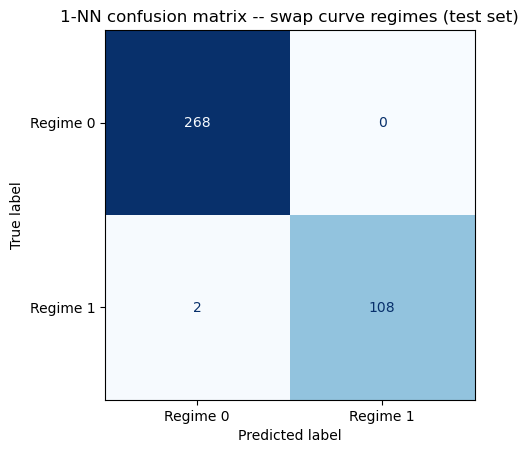

In [14]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=[f'Regime {i}' for i in sorted(set(regime_labels))])
disp.plot(cmap='Blues', colorbar=False)
plt.title('1-NN confusion matrix -- swap curve regimes (test set)')
plt.show()

#### Decision boundary on the two most informative tenors
To visualize *why* 1-NN classifies the way it does, we refit it on just the 1y and 10y swap rates and draw its decision regions -- with a single neighbor, the boundary tessellates the space around each individual training point.

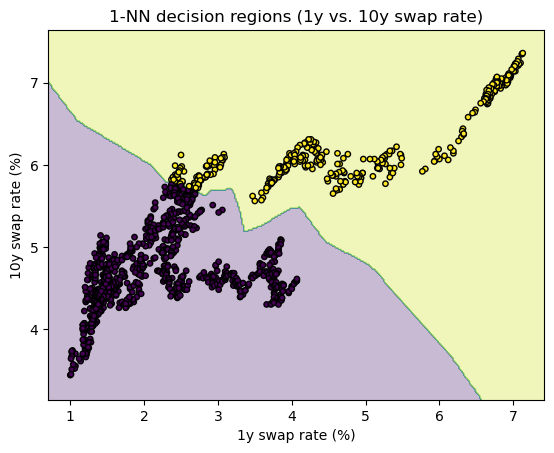

In [15]:
feat_x, feat_y = tenors.index('swp1y'), tenors.index('sw10y')
X2 = swap.values[:, [feat_x, feat_y]]

knn1_2d = KNeighborsClassifier(n_neighbors=1)
knn1_2d.fit(X2, regime_labels)

x_min, x_max = X2[:, 0].min() - 0.3, X2[:, 0].max() + 0.3
y_min, y_max = X2[:, 1].min() - 0.3, X2[:, 1].max() + 0.3
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
Z = knn1_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.scatter(X2[:, 0], X2[:, 1], c=regime_labels, edgecolor='k', s=15, cmap='viridis')
plt.xlabel('1y swap rate (%)'); plt.ylabel('10y swap rate (%)')
plt.title('1-NN decision regions (1y vs. 10y swap rate)')
plt.show()

## Part B

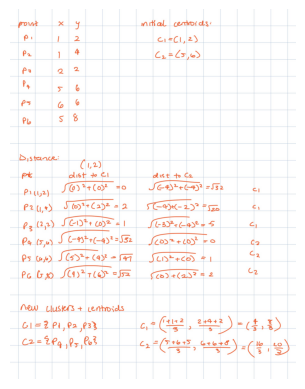

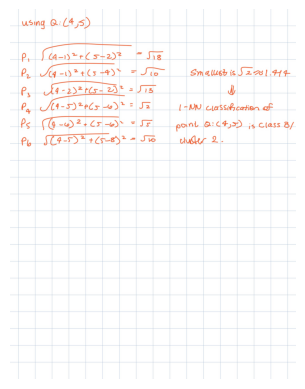

In [16]:
from PIL import Image
import matplotlib.pyplot as plt
img = Image.open(r"C:\Users\sromerod3\OneDrive\Documents\SEOUL 4803\hw 7 partb1.jpg")
plt.imshow(img)
plt.axis("off")
plt.show()
from PIL import Image
import matplotlib.pyplot as plt
img = Image.open(r"C:\Users\sromerod3\OneDrive\Documents\SEOUL 4803\hw 7 partb2.jpg")
plt.imshow(img)
plt.axis("off")
plt.show()

## Part C
### The Issue
One of the key issues is that the Euclidean distance calculation is fundamentally wrong since income is numerically 3000-4000 times larger than age. This results in the K-Means essentially only clustering around income alone and not considering age. The distance computation gets drowned out by minute income differences and remains unchanged even with big age gaps. This then places the centroid and draws the boundaries along the income axis, leaving the age-driven segments to be completely uncorrelated.
### The Fix

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = df[['age', 'income']].values
X_scaled = StandardScaler().fit_transform(X)   # <-- the fix

km = KMeans(n_clusters=3).fit(X_scaled)
df['cluster'] = km.labels_

NameError: name 'df' is not defined

This changes the clusters by aligning them correctly with the customer's age group. This creates three panels, with the left having three different clusters for customer age groups, the middle panel showing unscaled K-Means slicing data into horizontal income bands, and the right panel showing scaled K-means recovering vertical age-driven bands that match the true segment structure.
## Part D
1. Based on my part A, the silhouette scores on the swap-curve levels peaked at k=2. Therefore, about two clusters minimize confusion as best as possible.
2. A silhouette score actually measures the distance between my own cluster against the distance to nearest other cluster, closing the gap of inference on whtehr the clusters are actually far apart from each other.
3. Cluster variation is twice the sum of square distances to the clusters own mean. Meaning, that adding more clusters can never increase the sum. Therefore, every extra cetroid giving a point nearer to a mean doesnt actually increase k. And if you eventally push k -> n every point will have a perfect score since the data is memorized.
4. Scaling matters in the case of how sone feature's raw numeric range dwarfs the other. Leading one feature to dominate every term, it leads to the minimizatino to be a 1-D problem without realizing. So by scaling each feature contributes somewhat equally now and reflects genuine separation across all dimesnions at once. 